# 09 — Typed callbacks and audit

Callbacks are useful when an operational rule must intervene in a simulation without taking ownership of inventory accounting away from the engine. The important idea is not the Python subclass itself; it is the visible chain from the policy's proposal, through a typed callback result, to the validated event row.

This tutorial develops that chain one step at a time on the same deterministic five-SKU scenario:

1. hold a supplier order that does not reach a batch minimum;
2. record receiving-inspection breakage after daily demand; and
3. expedite predeclared priority items before the supplier gate and an ordinary constraint.

Each scenario constructs fresh inventory and a fresh fitted policy in full. The repeated setup is intentional: it lets you see exactly which objects enter every run and which callback or constraint is added next.

All results are conditional on the displayed synthetic demand and hypothetical operating assumptions. They teach mechanics and auditability, not that batching, breakage adjustments, or expediting is universally beneficial.

**Timing migration.** Decisions now precede current demand. `lead_time=0` means immediate receipt; positive lead times count forward from the decision epoch. Decision schedules use zero-based demand periods, while state/callback periods retain their existing coordinates. Forecasts exclude current demand. Numerical results from the former demand-first engine must be regenerated.


In [2]:
import json

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stockcast import (
    FixedPeriodicReviewTargets, InventoryAdjustmentResult,
    InventoryStateDataFrame, MaximumOrderQuantity, OrderAdjustmentResult,
    OrderingConstraints, PeriodicReviewPolicy, SimulationCallback,
    SimulationEngine,
)
from stockcast.evaluation import (
    InventoryEvaluator, avg_on_hand, demand_period_service_level, fill_rate,
    order_event_count, order_units, shortage_units, total_cost,
)

## 1. Declare one shared inventory scenario

We begin with the data and operating assumptions that remain fixed. Keeping them in one visible place is what makes the later scenario comparison meaningful.

- One period is one calendar day.
- Orders take two days to arrive.
- The policy reviews inventory every two days.
- Unmet demand is lost rather than backordered.
- There is no separate opening order before the first demand day.
- The first 14 days are scored; the final two days settle outstanding orders without creating new ones.

The five demand series are deterministic tutorial inputs rebuilt inside this notebook. They are not forecasts and are not loaded from another notebook. The fixed seed is explicitly `None` because no random generator is used.

In [3]:
# These identifiers define the complete SKU panel and its stable display order.
skus = ['tea', 'coffee', 'pasta', 'cereal', 'soup']

# The opening state is observed at the end of this date. Period-zero demand is one day later.
opening_date = pd.Timestamp('2026-03-01')
period_frequency = 'D'

# Lead time and review cadence are positive integers in Stockcast's discrete-period model.
lead_time = 2
review_period = 2

# Every simulated day belongs to exactly one evaluation window.
warmup_periods, scoring_periods, settlement_periods = 0, 14, 2
initial_decision = 'none'
order_during_settlement = False
random_seed = None

# Each list is the complete 16-day demand path for one SKU.
demand_values = {
    'tea':    [9.5, 6.8, 10.8, 8.1, 5.4, 9.5, 8.1, 12.2, 6.8, 8.1, 10.8, 9.5, 5.4, 12.2, 8.1, 6.8],
    'coffee': [5.4, 6.8, 8.1, 6.8, 9.5, 8.1, 5.4, 6.8, 8.1, 9.5, 6.8, 8.1, 5.4, 9.5, 6.8, 8.1],
    'pasta':  [6.8, 5.4, 8.1, 6.8, 5.4, 8.1, 6.8, 5.4, 8.1, 6.8, 9.5, 5.4, 6.8, 8.1, 5.4, 6.8],
    'cereal': [4.1, 6.8, 5.4, 8.1, 6.8, 4.1, 5.4, 8.1, 6.8, 5.4, 8.1, 6.8, 4.1, 8.1, 5.4, 6.8],
    'soup':   [2.7, 4.1, 5.4, 4.1, 6.8, 5.4, 4.1, 2.7, 5.4, 6.8, 4.1, 5.4, 2.7, 6.8, 4.1, 5.4],
}

# Stockcast requires one dated row for every SKU-period pair, with no missing days.
demand_dates = pd.date_range(
    opening_date + pd.Timedelta(days=1), periods=16, freq=period_frequency,
)
demand = pd.concat([
    pd.DataFrame({
        'unique_id': sku,
        'date': demand_dates,
        'period': range(16),
        'y': values,
    })
    for sku, values in demand_values.items()
], ignore_index=True)

# Five SKUs share sixteen dated periods starting the day after the opening state.
assert demand.groupby('unique_id').size().eq(16).all()
assert demand[['unique_id', 'period']].duplicated().sum() == 0
assert demand['date'].min() == opening_date + pd.Timedelta(days=1)

print('Synthetic demand panel (first six days)')
print(demand.pivot(index='date', columns='unique_id', values='y')[skus].head(6).to_string())

Synthetic demand panel (first six days)
unique_id    tea  coffee  pasta  cereal  soup
date                                         
2026-03-02   9.5     5.4    6.8     4.1   2.7
2026-03-03   6.8     6.8    5.4     6.8   4.1
2026-03-04  10.8     8.1    8.1     5.4   5.4
2026-03-05   8.1     6.8    6.8     8.1   4.1
2026-03-06   5.4     9.5    5.4     6.8   6.8
2026-03-07   9.5     8.1    8.1     4.1   5.4


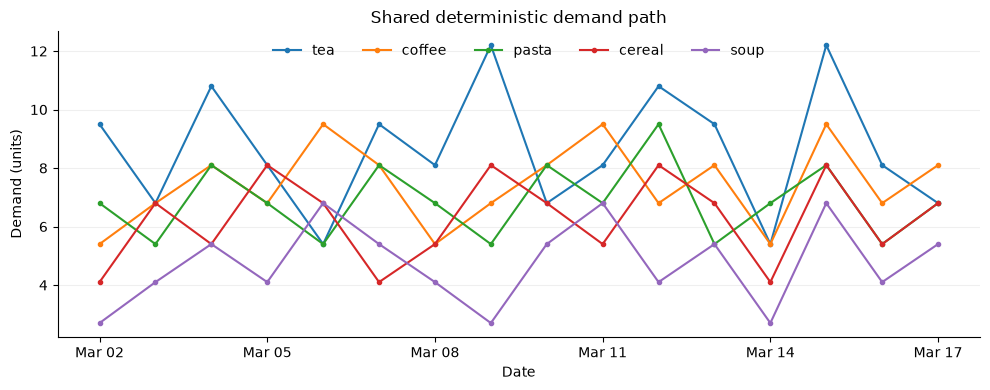

In [4]:
# Plot the exogenous demand before inventory decisions affect any outcome.
fig, ax = plt.subplots(figsize=(10, 4))
for sku in skus:
    rows = demand[demand['unique_id'].eq(sku)]
    ax.plot(rows['date'], rows['y'], marker='o', ms=3, lw=1.5, label=sku)

ax.set(title='Shared deterministic demand path', xlabel='Date', ylabel='Demand (units)')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(frameon=False, ncol=5, loc='upper center')
ax.grid(axis='y', alpha=.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

### Opening stock and the fixed periodic-review rule

The table below contains three different kinds of quantities:

- `opening_on_hand` is physical stock available at the opening date;
- `reorder_point` decides whether the periodic policy should replenish; and
- `order_up_to_level` is the inventory position the policy tries to restore.

These values are declared scenario inputs. They are not estimated from the future demand shown above. In each run we will pass the opening table to `InventoryStateDataFrame`, pass the two policy columns to `FixedPeriodicReviewTargets`, fit a new `PeriodicReviewPolicy`, and then call `SimulationEngine.run()` directly. Nothing about that path is hidden in a convenience function.

In [5]:
scenario_inputs = pd.DataFrame({
    'unique_id': skus,
    'opening_on_hand': [30.0, 26.0, 24.0, 22.0, 18.0],
    'reorder_point': [18.0, 15.0, 14.0, 12.0, 10.0],
    'order_up_to_level': [42.0, 35.0, 32.0, 29.0, 24.0],
})

# Keeping all three inputs beside each SKU makes the policy rule inspectable.
scenario_inputs

,unique_id,opening_on_hand,reorder_point,order_up_to_level
0,tea,30.0,18.0,42.0
1,coffee,26.0,15.0,35.0
2,pasta,24.0,14.0,32.0
3,cereal,22.0,12.0,29.0
4,soup,18.0,10.0,24.0


In [6]:
# Costs are evaluation assumptions: they value validated events after a run.
# They do not change demand, policy decisions, callbacks, or inventory transitions.
cost_context = {
    'cost_components': ['holding', 'shortage', 'ordering'],
    'holding_cost_per_unit_period': 0.10,
    'shortage_cost_per_unit': 2.00,
    'order_cost_per_sku_line': 0.50,
    'order_cost_per_unit': 0.00,
}
print('Hypothetical normalized ordinary-cost inputs')
print(pd.Series(cost_context, name='declared value').to_string())

Hypothetical normalized ordinary-cost inputs
cost_components                 [holding, shortage, ordering]
holding_cost_per_unit_period                              0.1
shortage_cost_per_unit                                    2.0
order_cost_per_sku_line                                   0.5
order_cost_per_unit                                       0.0


### Baseline: follow the complete path without callbacks

This first run establishes the ordinary engine behavior. Read the code from top to bottom:

1. initialize a fresh inventory state from the displayed opening stock;
2. create fixed reorder and order-up-to targets;
3. fit the periodic-review policy; and
4. pass the policy, demand, inventory, windows, and provenance into the engine.

The later scenarios repeat these same four steps. That repetition makes it possible to verify that each run starts from the same state instead of accidentally reusing the baseline's depleted inventory.

In [7]:
# 1. Build fresh caller-owned opening inventory for the baseline.
baseline_opening = scenario_inputs[['unique_id', 'opening_on_hand']].rename(
    columns={'opening_on_hand': 'observed_on_hand'}
)
baseline_inventory = InventoryStateDataFrame(
    skus, max_lead_time=lead_time, allow_backorders=False,
).initialize_from_observed(
    baseline_opening,
    on_hand_column='observed_on_hand',
    start_date=opening_date,
)
baseline_inventory

InventoryStateDataFrame(n_skus=5, total_on_hand=120, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

The inventory object now contains the five opening rows, an empty two-slot pipeline for each SKU, and the declared lost-sales mode. It is still caller-owned; the engine will copy it when the run begins.

Next, build and fit the replenishment rule from the displayed `reorder_point` and `order_up_to_level` columns.

In [8]:
# 2. Give the policy the fixed s and S values printed above.
baseline_targets = FixedPeriodicReviewTargets(
    reorder_point=scenario_inputs.set_index('unique_id')['reorder_point'].to_dict(),
    order_up_to_level=scenario_inputs.set_index('unique_id')['order_up_to_level'].to_dict(),
)

# 3. Fit a new periodic-review policy. The 0.95 value is metadata here,
# not a forecast probability or a guarantee about the realized fill rate.
baseline_policy = PeriodicReviewPolicy(
    lead_time=lead_time,
    review_period=review_period,
    service_level=0.95,
    allow_backorders=False,
).fit(
    pd.DataFrame({'unique_id': skus}),
    target_provider=baseline_targets,
    information_origin=opening_date,
    information_frequency=period_frequency,
)

The fitted policy can now produce a timed `OrderDecision` at eligible two-day reviews. It still does not mutate inventory. The engine call below combines that policy with demand and the fresh opening state.

In [9]:
# 4. Run the unmodified engine path. No callbacks or constraints are supplied.
baseline_result = SimulationEngine().run(
    policy=baseline_policy,
    demand_source=demand.copy(),
    inventory=baseline_inventory,
    n_periods=16,
    period_frequency=period_frequency,
    initial_decision=initial_decision,
    warmup_periods=warmup_periods,
    scoring_periods=scoring_periods,
    settlement_periods=settlement_periods,
    order_during_settlement=order_during_settlement,
    demand_source_name='declared_callback_panel',
    random_seed=random_seed,
)

baseline_events = baseline_result.to_event_frame(window='all')
print('Selected baseline period events')
print(baseline_events.query("event_type == 'period' and unique_id == 'soup'")[[
    'date', 'demand', 'received_units', 'requested_order_quantity',
    'order_quantity', 'ending_on_hand', 'shortage_units',
]].head(8).to_string(index=False))

Selected baseline period events
      date  demand  received_units  requested_order_quantity  order_quantity  ending_on_hand  shortage_units
2026-03-02     2.7             0.0                       0.0             0.0            15.3             0.0
2026-03-03     4.1             0.0                       0.0             0.0            11.2             0.0
2026-03-04     5.4             0.0                       0.0             0.0             5.8             0.0
2026-03-05     4.1             0.0                       0.0             0.0             1.7             0.0
2026-03-06     6.8             0.0                      22.3            22.3             0.0             5.1
2026-03-07     5.4             0.0                       0.0             0.0             0.0             5.4
2026-03-08     4.1            22.3                       0.0             0.0            18.2             0.0
2026-03-09     2.7             0.0                       0.0             0.0            15.5    

## 2. Understand the two callback phases

The engine still owns the simulation clock and every physical transition. During one period it performs this sequence:

```text
receive due pipeline stock
    -> fulfill daily demand
    -> on_after_demand callbacks
    -> policy prediction on an eligible review
    -> on_after_prediction callbacks in list order
    -> ordering constraints
    -> place one accepted order into the pipeline
    -> build and validate the event row
```

`on_after_demand` therefore sees the current receipt **after it has already been available to serve that day's demand**. `on_after_prediction` sees the policy's current proposed `OrderDecision`, before ordinary constraints alter it.

The callback receives defensive copies of the state and decision. Editing those copies has no effect on the run. To request a real intervention it must return one of the typed result objects:

- `InventoryAdjustmentResult` for a signed on-hand adjustment after demand;
- `OrderAdjustmentResult` for an absolute replacement order quantity after prediction; or
- `None` when it has nothing to do.

The engine validates identifiers, quantities, result type, and nonblank `reason`/`source` provenance before applying anything. Invalid output aborts the run instead of returning partially valid evidence. A callback cannot invent a new review date, bypass lead time, or add a second supplier decision.

## 3. Example 1 — hold an undersized supplier batch

Suppose the five SKUs are ordered from one supplier that accepts only a combined batch of at least 60 units. The callback must therefore inspect the **complete positive order panel**, not make five unrelated line-level decisions.

At an eligible review:

1. the policy calculates each SKU's request from current inventory position;
2. the callback sums only the positive lines;
3. a total below 60 is returned as zero for those lines; and
4. a total of 60 or more passes through unchanged by returning `None`.

The callback stores no rejected quantity. On the next review, the policy reads the then-current stock and pipeline and calculates a new request. This prevents a held prediction from being counted once in callback state and again in the policy's inventory calculation.

In [10]:
class SupplierBatchGate(SimulationCallback):
    """Hold the current positive supplier panel when it misses a batch minimum."""

    def __init__(self, minimum_batch_units, reason, source):
        # Constructor values are configuration, not state accumulated during a run.
        self.minimum_batch_units = float(minimum_batch_units)
        self.reason = reason
        self.source = source

    def on_after_prediction(self, decision, context):
        # get_dataframe() is a defensive copy of the policy decision composed so far.
        proposed = decision.get_dataframe()
        positive = proposed.loc[
            proposed['order_quantity'].gt(0), ['unique_id', 'order_quantity']
        ]

        # No positive order or a sufficiently large batch requires no intervention.
        if positive.empty or positive['order_quantity'].sum() >= self.minimum_batch_units:
            return None

        # Return absolute zero quantities only for the positive lines being held.
        held = positive.assign(
            order_quantity=0.0,
            reason=self.reason,
            source=self.source,
        )
        return OrderAdjustmentResult(
            held[['unique_id', 'order_quantity', 'reason', 'source']]
        )

    def get_config(self):
        # The manifest records constructor configuration, not the callback source code.
        return {
            'minimum_batch_units': self.minimum_batch_units,
            'reason': self.reason,
            'source': self.source,
        }


batch_gate = SupplierBatchGate(
    minimum_batch_units=60.0,
    reason='positive supplier panel below declared batch minimum',
    source='hypothetical tutorial batch rule',
)

In [11]:
# Start the batch scenario from a new copy of the displayed opening stock.
batch_opening = scenario_inputs[['unique_id', 'opening_on_hand']].rename(
    columns={'opening_on_hand': 'observed_on_hand'}
)
batch_inventory = InventoryStateDataFrame(
    skus, max_lead_time=lead_time, allow_backorders=False,
).initialize_from_observed(
    batch_opening,
    on_hand_column='observed_on_hand',
    start_date=opening_date,
)

This is a new inventory object, not the terminal state returned by the baseline. Reconstructing it visibly prevents a common comparison error: letting the second scenario inherit stock already consumed by the first.

In [12]:
# Recreate and fit the same policy rather than reusing mutable run objects.
batch_targets = FixedPeriodicReviewTargets(
    reorder_point=scenario_inputs.set_index('unique_id')['reorder_point'].to_dict(),
    order_up_to_level=scenario_inputs.set_index('unique_id')['order_up_to_level'].to_dict(),
)
batch_policy = PeriodicReviewPolicy(
    lead_time=lead_time,
    review_period=review_period,
    service_level=0.95,
    allow_backorders=False,
).fit(
    pd.DataFrame({'unique_id': skus}),
    target_provider=batch_targets,
    information_origin=opening_date,
    information_frequency=period_frequency,
)

The policy configuration and fitted targets are identical to the baseline. The next engine call changes only one experimental input: it supplies the batch callback.

In [13]:
# The only behavioral addition to the baseline call is callbacks=[batch_gate].
batch_result = SimulationEngine().run(
    policy=batch_policy,
    demand_source=demand.copy(),
    inventory=batch_inventory,
    n_periods=16,
    period_frequency=period_frequency,
    initial_decision=initial_decision,
    warmup_periods=warmup_periods,
    scoring_periods=scoring_periods,
    settlement_periods=settlement_periods,
    order_during_settlement=order_during_settlement,
    demand_source_name='declared_callback_panel',
    random_seed=random_seed,
    callbacks=[batch_gate],
)

batch_events = batch_result.to_event_frame(window='all')
batch_audit = batch_result.to_callback_audit_frame()

print('Accepted batch-gate audit rows')
print(batch_audit[[
    'date', 'unique_id', 'before_value', 'after_value', 'reason', 'source',
]].to_string(index=False))

print('\nMatching soup event rows')
print(batch_events.query("event_type == 'period' and unique_id == 'soup'")[[
    'date', 'requested_order_quantity', 'callback_adjusted_order_quantity',
    'order_quantity', 'received_units', 'ending_on_hand', 'shortage_units',
]].head(8).to_string(index=False))

Accepted batch-gate audit rows
      date unique_id  before_value  after_value                                               reason                           source
2026-03-06      soup          22.3          0.0 positive supplier panel below declared batch minimum hypothetical tutorial batch rule
2026-03-14      soup          21.7          0.0 positive supplier panel below declared batch minimum hypothetical tutorial batch rule

Matching soup event rows
      date  requested_order_quantity  callback_adjusted_order_quantity  order_quantity  received_units  ending_on_hand  shortage_units
2026-03-02                       0.0                               0.0             0.0             0.0            15.3             0.0
2026-03-03                       0.0                               0.0             0.0             0.0            11.2             0.0
2026-03-04                       0.0                               0.0             0.0             0.0             5.8             0.0
2

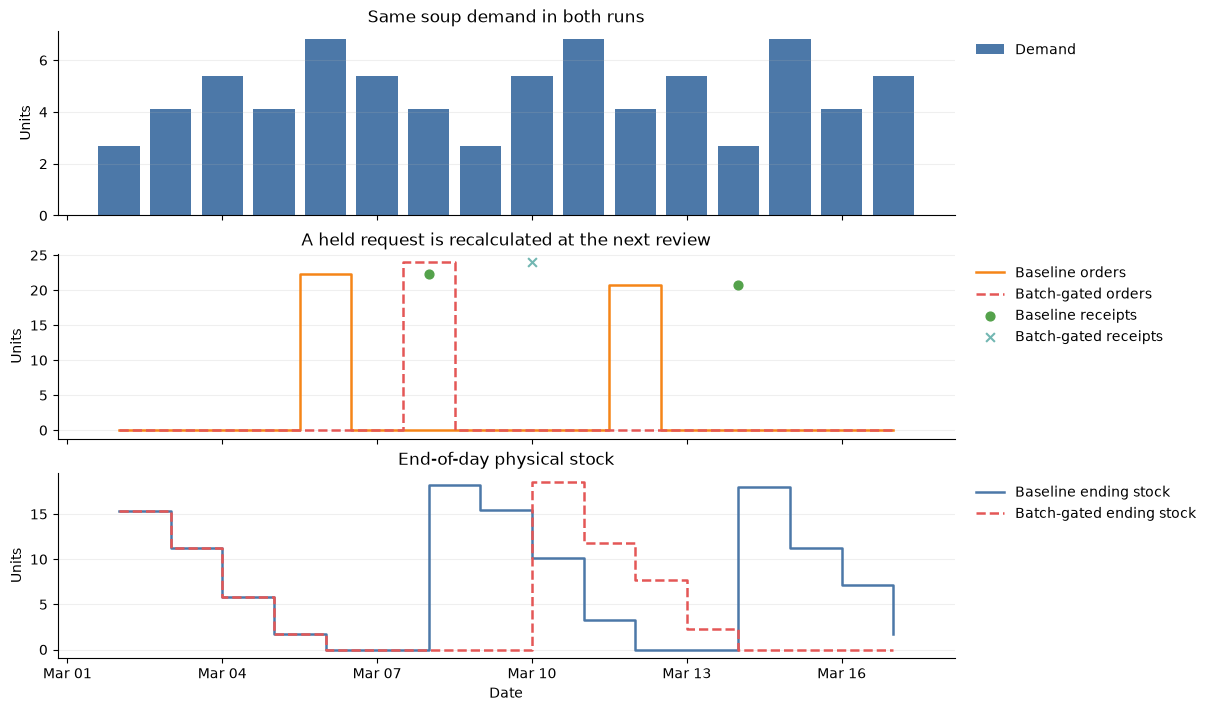

In [14]:
# Soup is the clearest line-level example of the portfolio batch decision.
base_soup = baseline_events.query("event_type == 'period' and unique_id == 'soup'")
batch_soup = batch_events.query("event_type == 'period' and unique_id == 'soup'")

fig, axes = plt.subplots(
    3, 1, figsize=(12, 7), sharex=True, layout='constrained',
)

# Demand is identical in both runs, so it needs only one panel.
axes[0].bar(base_soup['date'], base_soup['demand'], color='#4C78A8', label='Demand')
axes[0].set(title='Same soup demand in both runs', ylabel='Units')

# Orders are decision-period flows; receipts show their delayed physical arrival.
for rows, label, color, linestyle in [
    (base_soup, 'Baseline orders', '#F58518', '-'),
    (batch_soup, 'Batch-gated orders', '#E45756', '--'),
]:
    axes[1].step(
        rows['date'], rows['order_quantity'], where='mid',
        color=color, linestyle=linestyle, lw=1.8, label=label,
    )
for rows, label, color, marker in [
    (base_soup, 'Baseline receipts', '#54A24B', 'o'),
    (batch_soup, 'Batch-gated receipts', '#72B7B2', 'x'),
]:
    positive = rows[rows['received_units'].gt(0)]
    axes[1].scatter(
        positive['date'], positive['received_units'], color=color,
        marker=marker, s=40, label=label, zorder=3,
    )
axes[1].set(title='A held request is recalculated at the next review', ylabel='Units')

# Ending stock is the validated state after receipts, demand, and any adjustment.
axes[2].step(
    base_soup['date'], base_soup['ending_on_hand'], where='post',
    color='#4C78A8', lw=1.8, label='Baseline ending stock',
)
axes[2].step(
    batch_soup['date'], batch_soup['ending_on_hand'], where='post',
    color='#E45756', linestyle='--', lw=1.8, label='Batch-gated ending stock',
)
axes[2].set(title='End-of-day physical stock', xlabel='Date', ylabel='Units')
axes[2].xaxis.set_major_locator(mdates.DayLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

for ax in axes:
    # Place legends outside the axes so they never cover lines or receipt markers.
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
    ax.grid(axis='y', alpha=.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()

The first held soup request is 22.3 units. The audit records `before_value=22.3` and `after_value=0`, while the matching event keeps the same 22.3 as `requested_order_quantity` and records zero as both the callback-adjusted and accepted order.

Two days later the policy does **not** receive 22.3 units, because the held request never entered the pipeline. It reads the depleted current inventory, requests 24 units, and that request is accepted because the complete supplier panel at that review clears the 60-unit threshold. The chart therefore shows a delayed recalculation, not callback accumulation.

## 4. Example 2 — record receiving-inspection breakage

Now add a physical adjustment equal to 2% of the units received on the current day. The timing needs careful language:

1. pipeline slot zero is received;
2. that receipt can clear backlog and serve current demand;
3. `on_after_demand` then receives a defensive view containing `latest_received`; and
4. the callback requests a negative on-hand adjustment based on that receipt.

This is a **2% receiving-inspection breakage adjustment recorded after daily demand**. It is not literal in-transit loss and it does not remove goods before they can serve demand. Exact pre-demand transit loss is not supported by this callback phase.

The adjustment is sparse: on days without receipts the callback returns `None`. The scenario is constructed so each negative adjustment is no larger than post-demand on-hand. If that were not true, the engine would fail the run rather than allow negative physical stock.

In [15]:
class ReceivingInspectionBreakage(SimulationCallback):
    """Remove a declared fraction of current receipts after daily demand."""

    def __init__(self, loss_fraction, reason, source):
        # These values remain constant across runs; the callback keeps no counters.
        self.loss_fraction = float(loss_fraction)
        self.reason = reason
        self.source = source

    def on_after_demand(self, context):
        # latest_received records what entered from the pipeline earlier this day.
        received = context.inventory.loc[
            context.inventory['latest_received'].gt(0),
            [context.sku_column, 'latest_received'],
        ].copy()
        if received.empty:
            return None

        # Inventory adjustments are signed: a negative delta removes on-hand units.
        received['quantity_delta'] = -self.loss_fraction * received['latest_received']
        received['reason'] = self.reason
        received['source'] = self.source
        return InventoryAdjustmentResult(
            received.rename(columns={context.sku_column: 'unique_id'})[[
                'unique_id', 'quantity_delta', 'reason', 'source',
            ]]
        )

    def get_config(self):
        return {
            'loss_fraction': self.loss_fraction,
            'reason': self.reason,
            'source': self.source,
        }


receiving_breakage = ReceivingInspectionBreakage(
    loss_fraction=0.02,
    reason='receiving-inspection breakage recorded after daily demand',
    source='hypothetical tutorial breakage rule',
)

In [16]:
# Again, construct fresh physical state from the original opening table.
breakage_opening = scenario_inputs[['unique_id', 'opening_on_hand']].rename(
    columns={'opening_on_hand': 'observed_on_hand'}
)
breakage_inventory = InventoryStateDataFrame(
    skus, max_lead_time=lead_time, allow_backorders=False,
).initialize_from_observed(
    breakage_opening,
    on_hand_column='observed_on_hand',
    start_date=opening_date,
)

The third run also begins from the original physical stock and empty pipelines. Callback reuse does not imply inventory reuse: the callback objects hold configuration, while every `InventoryStateDataFrame` is newly initialized.

In [17]:
# Recreate the identical fixed-target policy used by the first two runs.
breakage_targets = FixedPeriodicReviewTargets(
    reorder_point=scenario_inputs.set_index('unique_id')['reorder_point'].to_dict(),
    order_up_to_level=scenario_inputs.set_index('unique_id')['order_up_to_level'].to_dict(),
)
breakage_policy = PeriodicReviewPolicy(
    lead_time=lead_time,
    review_period=review_period,
    service_level=0.95,
    allow_backorders=False,
).fit(
    pd.DataFrame({'unique_id': skus}),
    target_provider=breakage_targets,
    information_origin=opening_date,
    information_frequency=period_frequency,
)

With state and policy held fixed, the engine call adds two callbacks. Their Python list positions are recorded in the manifest, but phase determines when each method is invoked.

In [18]:
# Callback list order is explicit. The two callbacks use different phases:
# receiving_breakage runs after demand; batch_gate runs after prediction.
batch_breakage_result = SimulationEngine().run(
    policy=breakage_policy,
    demand_source=demand.copy(),
    inventory=breakage_inventory,
    n_periods=16,
    period_frequency=period_frequency,
    initial_decision=initial_decision,
    warmup_periods=warmup_periods,
    scoring_periods=scoring_periods,
    settlement_periods=settlement_periods,
    order_during_settlement=order_during_settlement,
    demand_source_name='declared_callback_panel',
    random_seed=random_seed,
    callbacks=[batch_gate, receiving_breakage],
)

breakage_events = batch_breakage_result.to_event_frame(window='all')
breakage_audit = batch_breakage_result.to_callback_audit_frame()

# Join each physical callback row to the one validated SKU-period event it changed.
physical_audit = breakage_audit.query("phase == 'on_after_demand'")
matched_physical = physical_audit.merge(
    breakage_events[['unique_id', 'period', 'date', 'received_units',
                      'inventory_adjustment_units', 'ending_on_hand', 'shortage_units']],
    on=['unique_id', 'period', 'date'], how='left', validate='one_to_one',
)
print('Selected breakage audit rows matched to validated events')
print(matched_physical[[
    'date', 'unique_id', 'received_units', 'before_value', 'quantity_delta',
    'inventory_adjustment_units', 'after_value', 'ending_on_hand',
]].head(10).round(3).to_string(index=False))

Selected breakage audit rows matched to validated events
      date unique_id  received_units  before_value  quantity_delta  inventory_adjustment_units  after_value  ending_on_hand
2026-03-06       tea          28.300        22.900          -0.566                      -0.566       22.334          22.334
2026-03-06    coffee          21.200        11.700          -0.424                      -0.424       11.276          11.276
2026-03-06     pasta          20.200        14.800          -0.404                      -0.404       14.396          14.396
2026-03-06    cereal          17.900        11.100          -0.358                      -0.358       10.742          10.742
2026-03-10       tea          29.166        22.366          -0.583                      -0.583       21.783          21.783
2026-03-10    coffee          31.824        23.724          -0.636                      -0.636       23.088          23.088
2026-03-10     pasta          25.704        17.604          -0.514         

/tmp/ipykernel_1170170/503543039.py:33: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ]].head(10).round(3).to_string(index=False))


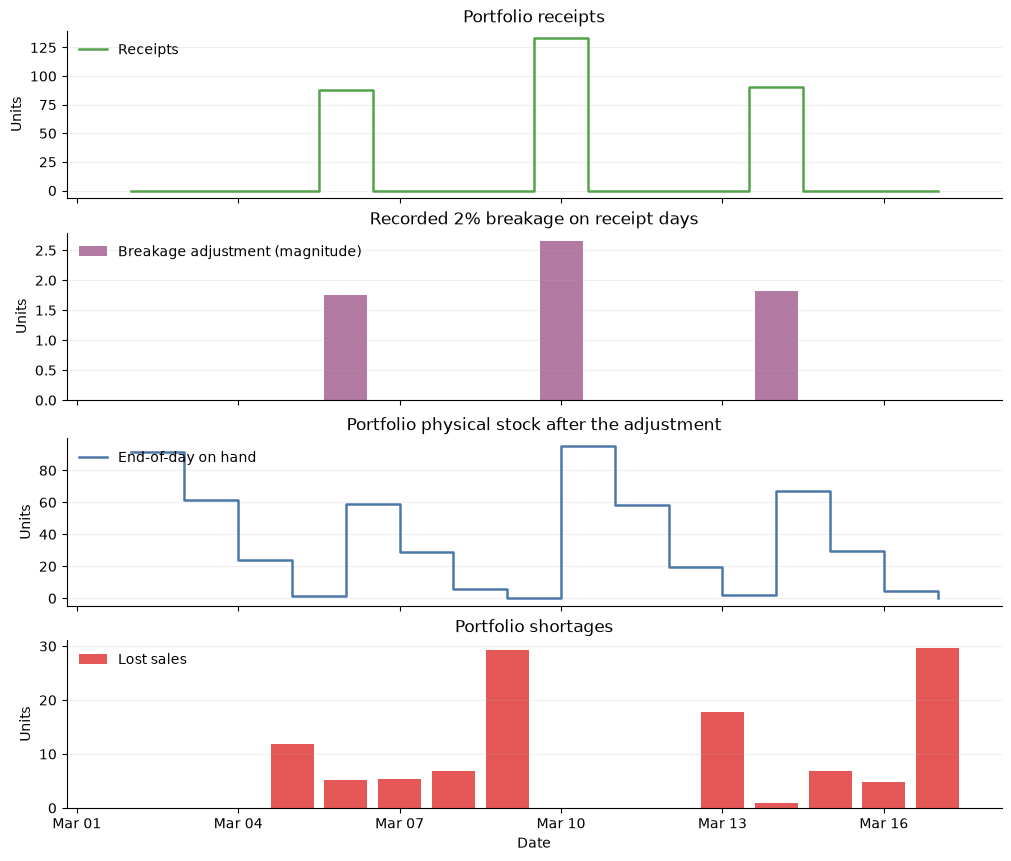

In [19]:
# Portfolio aggregation is safe here because all five SKUs share each date and unit.
portfolio = breakage_events.query("event_type == 'period'").groupby(
    'date', as_index=False,
).agg(
    receipts=('received_units', 'sum'),
    breakage_adjustment=('inventory_adjustment_units', 'sum'),
    ending_stock=('ending_on_hand', 'sum'),
    shortage=('shortage_units', 'sum'),
)

# The event ledger stores removals as negative deltas; the plot uses positive magnitude.
portfolio['breakage_units'] = -portfolio['breakage_adjustment']

fig, axes = plt.subplots(4, 1, figsize=(10, 8.5), sharex=True, layout='constrained')
axes[0].step(
    portfolio['date'], portfolio['receipts'], where='mid',
    color='#54A24B', lw=1.8, label='Receipts',
)
axes[0].set(title='Portfolio receipts', ylabel='Units')

# Breakage has its own ordinary-unit scale so the 2% values remain visible.
axes[1].bar(
    portfolio['date'], portfolio['breakage_units'],
    color='#B279A2', label='Breakage adjustment (magnitude)',
)
axes[1].set(title='Recorded 2% breakage on receipt days', ylabel='Units')

axes[2].step(
    portfolio['date'], portfolio['ending_stock'], where='post',
    color='#4C78A8', lw=1.8, label='End-of-day on hand',
)
axes[2].set(title='Portfolio physical stock after the adjustment', ylabel='Units')

axes[3].bar(portfolio['date'], portfolio['shortage'], color='#E45756', label='Lost sales')
axes[3].set(title='Portfolio shortages', xlabel='Date', ylabel='Units')
axes[3].xaxis.set_major_locator(mdates.DayLocator(interval=3))
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

for ax in axes:
    ax.legend(frameon=False, loc='upper left')
    ax.grid(axis='y', alpha=.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()

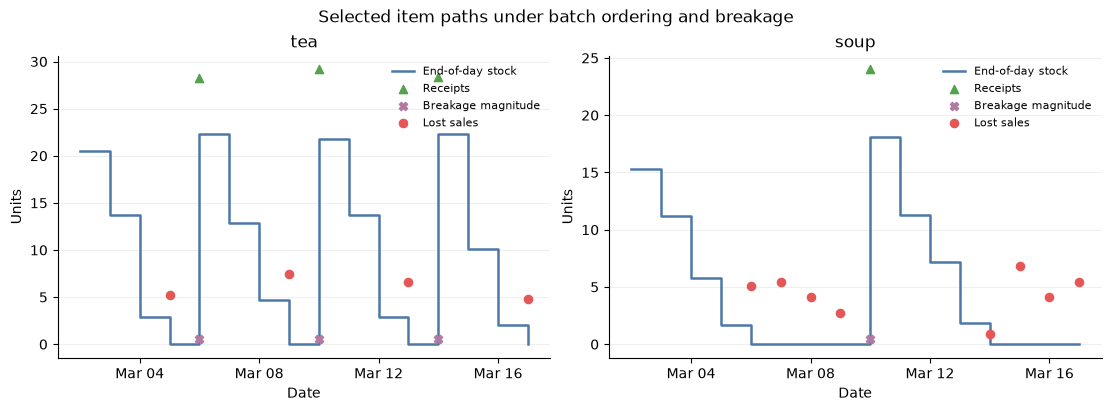

In [20]:
# Tea and soup make the same timing visible without a giant per-SKU table.
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, layout='constrained')
for ax, sku in zip(axes, ['tea', 'soup']):
    rows = breakage_events.query(
        "event_type == 'period' and unique_id == @sku"
    ).sort_values('date')

    # The step line is end-of-day physical stock after the callback adjustment.
    ax.step(
        rows['date'], rows['ending_on_hand'], where='post',
        color='#4C78A8', lw=1.8, label='End-of-day stock',
    )
    for field, marker, color, label in [
        ('received_units', '^', '#54A24B', 'Receipts'),
        ('inventory_adjustment_units', 'X', '#B279A2', 'Breakage magnitude'),
        ('shortage_units', 'o', '#E45756', 'Lost sales'),
    ]:
        # Plot only positive magnitudes so zero markers do not obscure the path.
        values = rows[field].abs() if field == 'inventory_adjustment_units' else rows[field]
        positive = rows.loc[values.gt(0)].copy()
        plotted = positive[field].abs() if field == 'inventory_adjustment_units' else positive[field]
        ax.scatter(
            positive['date'], plotted, marker=marker, color=color,
            s=35, zorder=3, label=label,
        )

    ax.set(title=sku, xlabel='Date', ylabel='Units')
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.legend(frameon=False, fontsize=8)
    ax.grid(axis='y', alpha=.2)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Selected item paths under batch ordering and breakage')
plt.show()

## 5. Example 3 — expedite predeclared priority items

Tea and soup are declared priority items **before** this run. Their importance is a hypothetical operating assumption; it is not inferred from their realized shortages or from which plot looks most interesting.

At each normal policy review, the callback calculates current inventory position:

```text
inventory position = on-hand + pipeline - backorders
```

If a priority item's position is below 25 and the policy proposes fewer than 28 units, the callback replaces that line with an absolute 28-unit proposal. Otherwise it returns `None`.

The order callback list is deliberately `[priority_expedite, batch_gate, receiving_breakage]`. Within `on_after_prediction`, the expedite runs first and the supplier batch gate sees its result. `receiving_breakage` appears later in the Python list but runs in the earlier `on_after_demand` phase. Finally, a standard maximum-order constraint caps tea and soup at 24 units. This exposes the full trail:

```text
policy request -> priority expedite -> supplier batch gate -> maximum constraint -> accepted order
```

In [21]:
class PriorityItemExpedite(SimulationCallback):
    """Raise eligible priority-item proposals to one declared quantity."""

    def __init__(self, priority_skus, inventory_position_threshold,
                 expedite_quantity, reason, source):
        # Priority is fixed before the run; no outcome-dependent state is retained.
        self.priority_skus = list(priority_skus)
        self.inventory_position_threshold = float(inventory_position_threshold)
        self.expedite_quantity = float(expedite_quantity)
        self.reason = reason
        self.source = source

    def on_after_prediction(self, decision, context):
        # Start from the current composed order proposal and defensive inventory view.
        proposed = decision.get_dataframe()[['unique_id', 'order_quantity']].copy()
        state = context.inventory.set_index(context.sku_column)

        # Pipeline arrays contain orders already accepted but not yet received.
        inventory_position = (
            state['on_hand']
            + state['in_transit'].map(lambda values: float(np.sum(values)))
            - state['backorders']
        )
        proposed['inventory_position'] = proposed['unique_id'].map(inventory_position)

        # Only listed priority SKUs below the threshold can be raised.
        eligible = proposed[
            proposed['unique_id'].isin(self.priority_skus)
            & proposed['inventory_position'].lt(self.inventory_position_threshold)
            & proposed['order_quantity'].lt(self.expedite_quantity)
        ].copy()
        if eligible.empty:
            return None

        # OrderAdjustmentResult uses absolute quantities, not incremental deltas.
        eligible['order_quantity'] = self.expedite_quantity
        eligible['reason'] = self.reason
        eligible['source'] = self.source
        return OrderAdjustmentResult(
            eligible[['unique_id', 'order_quantity', 'reason', 'source']]
        )

    def get_config(self):
        return {
            'priority_skus': self.priority_skus,
            'inventory_position_threshold': self.inventory_position_threshold,
            'expedite_quantity': self.expedite_quantity,
            'reason': self.reason,
            'source': self.source,
        }


priority_expedite = PriorityItemExpedite(
    priority_skus=['tea', 'soup'],
    inventory_position_threshold=25.0,
    expedite_quantity=28.0,
    reason='priority item below declared inventory-position threshold',
    source='hypothetical tutorial expedite rule',
)

In [22]:
# The constraint is engine-owned and runs after both order callbacks.
maximum_order = OrderingConstraints([
    MaximumOrderQuantity(
        {
            'tea': 24.0, 'coffee': 100.0, 'pasta': 100.0,
            'cereal': 100.0, 'soup': 24.0,
        },
        mode='adjust',
    )
])

The maximum-order rule is a normal engine constraint, not callback logic. It receives the order only after the priority and batch callbacks have finished composing it.

In [23]:
# Construct fresh opening state for the fourth scenario.
all_opening = scenario_inputs[['unique_id', 'opening_on_hand']].rename(
    columns={'opening_on_hand': 'observed_on_hand'}
)
all_inventory = InventoryStateDataFrame(
    skus, max_lead_time=lead_time, allow_backorders=False,
).initialize_from_observed(
    all_opening,
    on_hand_column='observed_on_hand',
    start_date=opening_date,
)

As before, construct opening inventory from the original scenario table. The final cumulative run must not inherit physical state from the batch-and-breakage result.

In [24]:
# Fit another independent copy of the same fixed periodic-review policy.
all_targets = FixedPeriodicReviewTargets(
    reorder_point=scenario_inputs.set_index('unique_id')['reorder_point'].to_dict(),
    order_up_to_level=scenario_inputs.set_index('unique_id')['order_up_to_level'].to_dict(),
)
all_policy = PeriodicReviewPolicy(
    lead_time=lead_time,
    review_period=review_period,
    service_level=0.95,
    allow_backorders=False,
).fit(
    pd.DataFrame({'unique_id': skus}),
    target_provider=all_targets,
    information_origin=opening_date,
    information_frequency=period_frequency,
)

Fit the same periodic policy one last time. The final engine call can then isolate the declared callback list and maximum constraint as its added operating rules.

In [25]:
# List order matters within on_after_prediction: expedite precedes the batch gate.
all_callbacks = [priority_expedite, batch_gate, receiving_breakage]
all_callbacks_result = SimulationEngine().run(
    policy=all_policy,
    demand_source=demand.copy(),
    inventory=all_inventory,
    n_periods=16,
    period_frequency=period_frequency,
    initial_decision=initial_decision,
    warmup_periods=warmup_periods,
    scoring_periods=scoring_periods,
    settlement_periods=settlement_periods,
    order_during_settlement=order_during_settlement,
    demand_source_name='declared_callback_panel',
    random_seed=random_seed,
    callbacks=all_callbacks,
    order_constraints=maximum_order,
)

all_events = all_callbacks_result.to_event_frame(window='all')
all_audit = all_callbacks_result.to_callback_audit_frame()

In [26]:
# The manifest preserves list position, enabled phase, and constructor configuration.
manifest_callbacks = all_callbacks_result.run_manifest['run_settings']['callbacks']
manifest_view = pd.DataFrame([{
    'position': item['position'],
    'class': item['class'],
    'enabled_phases': ', '.join(item['enabled_phases']),
    'config': json.dumps(item['config'], sort_keys=True),
} for item in manifest_callbacks])
print('Callback order and configuration retained in the manifest')
print(manifest_view.to_string(index=False))

# Constraint order is recorded separately because constraints run after callbacks.
constraint_manifest = all_callbacks_result.run_manifest['run_settings']['order_constraints']
print('\nConstraint application order')
print(constraint_manifest['application_order'])

Callback order and configuration retained in the manifest
 position                       class      enabled_phases                                                                                                                                                                                                                      config
        0        PriorityItemExpedite on_after_prediction {"expedite_quantity": 28.0, "inventory_position_threshold": 25.0, "priority_skus": ["tea", "soup"], "reason": "priority item below declared inventory-position threshold", "source": "hypothetical tutorial expedite rule"}
        1           SupplierBatchGate on_after_prediction                                                                               {"minimum_batch_units": 60.0, "reason": "positive supplier panel below declared batch minimum", "source": "hypothetical tutorial batch rule"}
        2 ReceivingInspectionBreakage     on_after_demand                                                   

### Match local callback effects to the finalized order trail

One audit row describes one callback's local change:

- `before_value` is the quantity entering that callback;
- `after_value` is the absolute quantity it returned; and
- `callback_position` identifies list order.

The matching canonical event then summarizes the entire decision opportunity:

- `requested_order_quantity` is the policy output;
- `callback_adjusted_order_quantity` is the result after all order callbacks;
- `constrained_order_quantity` is the quantity after the maximum constraint; and
- `order_quantity` is the final quantity accepted into the lead-time pipeline.

A callback can turn a zero proposal into a positive order, but it still acts inside an existing review. It cannot add another review or a second supplier event for the same opportunity.

In [27]:
# Rename the callback-local order column before joining the final event quantity.
order_audit = all_audit.query("phase == 'on_after_prediction'").rename(
    columns={'order_quantity': 'callback_returned_order'}
).merge(
    all_events[['unique_id', 'period', 'date', 'requested_order_quantity',
                'callback_adjusted_order_quantity', 'constrained_order_quantity',
                'order_quantity', 'binding_constraints']],
    on=['unique_id', 'period', 'date'],
    how='left',
    validate='many_to_one',
)

# Keep only the two order-callback classes needed to read the composition sequence.
selected_order_audit = order_audit[
    order_audit['callback_class'].isin(['PriorityItemExpedite', 'SupplierBatchGate'])
]
print('Selected callback rows matched to the final order trail')
print(selected_order_audit[[
    'date', 'unique_id', 'callback_position', 'callback_class',
    'before_value', 'after_value', 'callback_returned_order',
    'requested_order_quantity', 'callback_adjusted_order_quantity',
    'constrained_order_quantity', 'order_quantity', 'binding_constraints',
]].head(14).round(3).to_string(index=False))

Selected callback rows matched to the final order trail
      date unique_id  callback_position       callback_class  before_value  after_value  callback_returned_order  requested_order_quantity  callback_adjusted_order_quantity  constrained_order_quantity  order_quantity    binding_constraints
2026-03-02      soup                  0 PriorityItemExpedite           0.0         28.0                     28.0                       0.0                               0.0                         0.0             0.0                       
2026-03-02      soup                  1    SupplierBatchGate          28.0          0.0                      0.0                       0.0                               0.0                         0.0             0.0                       
2026-03-04      soup                  0 PriorityItemExpedite           0.0         28.0                     28.0                       0.0                              28.0                        24.0            24.0 maximum

/tmp/ipykernel_1170170/2511665120.py:23: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ]].head(14).round(3).to_string(index=False))


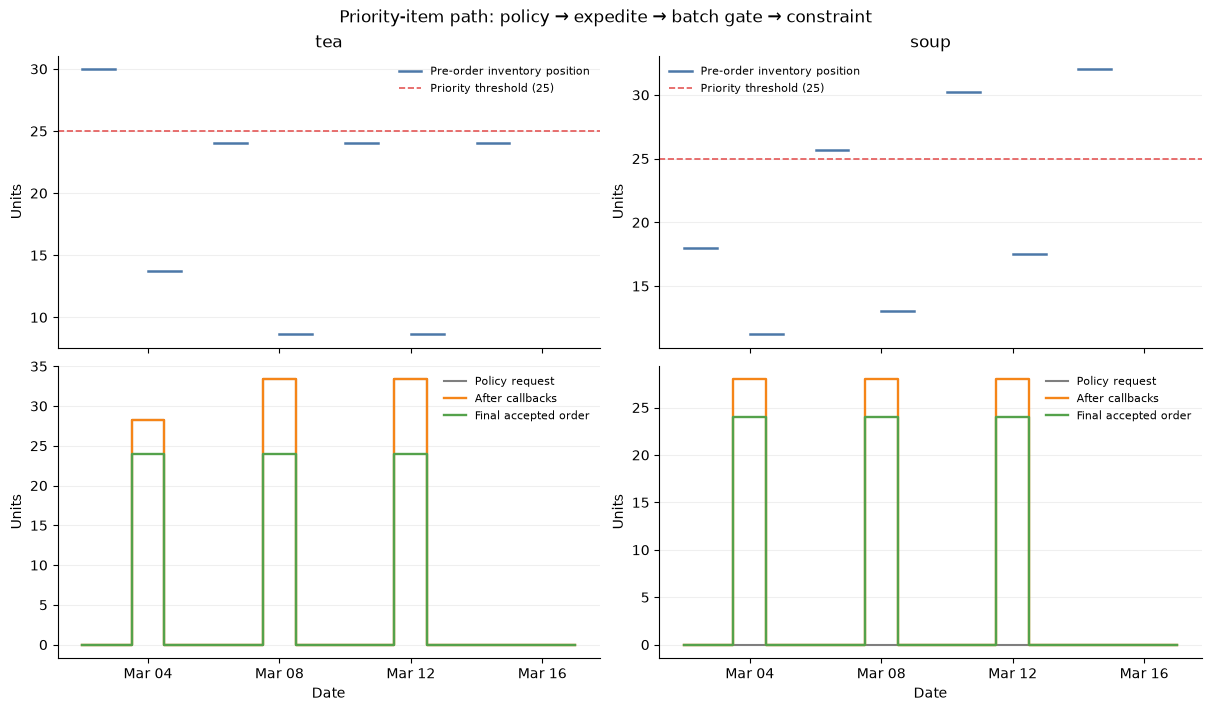

In [28]:
# These items were chosen before the run as the hypothetical priority set.
priority_items = ['tea', 'soup']
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex='col', layout='constrained')

for column, sku in enumerate(priority_items):
    rows = all_events.query(
        "event_type == 'period' and unique_id == @sku"
    ).sort_values('date').copy()

    # Read the actual pre-demand decision snapshot; closing position includes demand.
    rows['pre_order_inventory_position'] = (
        rows['decision_inventory_position']
    )
    axes[0, column].step(
        rows['date'], rows['pre_order_inventory_position'], where='post',
        color='#4C78A8', lw=1.8, label='Pre-order inventory position',
    )
    axes[0, column].axhline(
        25.0, color='#E45756', ls='--', lw=1.2,
        label='Priority threshold (25)',
    )
    axes[0, column].set(title=sku, ylabel='Units')

    # The three lines expose policy output, callback composition, and acceptance.
    axes[1, column].step(
        rows['date'], rows['requested_order_quantity'], where='mid',
        color='#7F7F7F', lw=1.5, label='Policy request',
    )
    axes[1, column].step(
        rows['date'], rows['callback_adjusted_order_quantity'], where='mid',
        color='#F58518', lw=1.7, label='After callbacks',
    )
    axes[1, column].step(
        rows['date'], rows['order_quantity'], where='mid',
        color='#54A24B', lw=1.7, label='Final accepted order',
    )
    axes[1, column].set(xlabel='Date', ylabel='Units')
    axes[1, column].xaxis.set_major_locator(mdates.DayLocator(interval=4))
    axes[1, column].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

for ax in axes.flat:
    ax.legend(frameon=False, fontsize=8)
    ax.grid(axis='y', alpha=.2)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Priority-item path: policy → expedite → batch gate → constraint')
plt.show()

## 6. Evaluate the same scoring window and add intervention cost

`InventoryEvaluator` reads validated scoring events. For each scenario we request the same pooled service, shortage, stock, ordering, and ordinary-cost metrics. The signed `inventory_adjustment_units` total is read directly from the same scoring events.

Expediting uses a separate hypothetical normalized cost of 3.00 per **accepted scoring-window trigger**. We calculate that evidence visibly inside the loop:

1. select priority-expedite audit rows that raised the policy proposal;
2. join them to scoring events by SKU, period, and date;
3. count a trigger only when the final accepted order remains above the callback's `before_value`; and
4. multiply that accepted count by 3.00.

This avoids charging an expedite intervention that the later batch gate fully held. The rate is a tutorial assumption, not real retail data, and remains separate from Stockcast's ordinary cost components.

In [29]:
expedite_cost_per_accepted_trigger = 3.00
scenario_results = {
    'Baseline': baseline_result,
    'Batch gate': batch_result,
    'Batch + breakage': batch_breakage_result,
    'All three + max constraint': all_callbacks_result,
}

comparison_rows = []
for name, result in scenario_results.items():
    # Evaluate every run on the identical 14-day scoring window and pooled grain.
    measures = InventoryEvaluator().fit(
        simulation_result=result,
        window='scoring',
    ).evaluate(
        metrics=[
            fill_rate, demand_period_service_level, shortage_units,
            avg_on_hand, order_units, order_event_count, total_cost,
        ],
        groupby=[],
        context=cost_context,
    ).iloc[0]
    scoring_events = result.to_event_frame(window='scoring')

    # Start with no intervention charge; only priority-expedite rows can add one.
    accepted_triggers = 0
    callback_audit = result.to_callback_audit_frame()
    priority_audit = callback_audit[
        callback_audit['callback_class'].eq('PriorityItemExpedite')
        & callback_audit['phase'].eq('on_after_prediction')
        & callback_audit['after_value'].gt(callback_audit['before_value'])
    ].drop(columns=['order_quantity'])

    if not priority_audit.empty:
        # The inner join also restricts intervention cost to scoring-window evidence.
        matched_expedites = priority_audit.merge(
            scoring_events[['unique_id', 'period', 'date', 'order_quantity']],
            on=['unique_id', 'period', 'date'],
            how='inner',
            validate='one_to_one',
        )
        # A later gate or constraint may reduce the quantity; charge only what survives.
        accepted_triggers = int(
            matched_expedites['order_quantity'].gt(
                matched_expedites['before_value']
            ).sum()
        )

    expedite_cost = accepted_triggers * expedite_cost_per_accepted_trigger
    comparison_rows.append({
        'scenario': name,
        **measures.to_dict(),
        'inventory_adjustment_units': scoring_events['inventory_adjustment_units'].sum(),
        'accepted_expedite_triggers': accepted_triggers,
        'expedite_cost': expedite_cost,
        'total_cost_including_interventions': measures['total_cost'] + expedite_cost,
    })

comparison = pd.DataFrame(comparison_rows).rename(
    columns={'total_cost': 'ordinary_cost'}
)
print(comparison.round(3).to_string(index=False))

                  scenario  fill_rate  demand_period_service_level  shortage_units  avg_on_hand  order_units  order_event_count  ordinary_cost  inventory_adjustment_units  accepted_expedite_triggers  expedite_cost  total_cost_including_interventions
                  Baseline      0.847                        0.743          73.300        8.429      328.200                4.0        212.600                       0.000                           0            0.0                             212.600
                Batch gate      0.831                        0.714          81.100        7.916      309.200                3.0        224.110                       0.000                           0            0.0                             224.110
          Batch + breakage      0.825                        0.714          83.761        7.767      311.381                3.0        228.391                      -6.228                           0            0.0                             228.391


### Plot the aggregated operational results

The comparison table is the exact output; these bars make its main operational differences easier to scan. Each panel has its own y-axis because percentages, physical units, average stock, and ordered units are different quantities and should not be forced onto one scale.

- Fill rate is shown as a percentage of demanded units fulfilled immediately.
- Shortage units are the corresponding unmet physical units in the scoring window.
- Average on-hand is the mean ending stock per SKU-period.
- Order units sum accepted replenishment across the scoring window.

The panels should be read together. For example, a stock or ordering reduction is not automatically desirable if shortages rise.

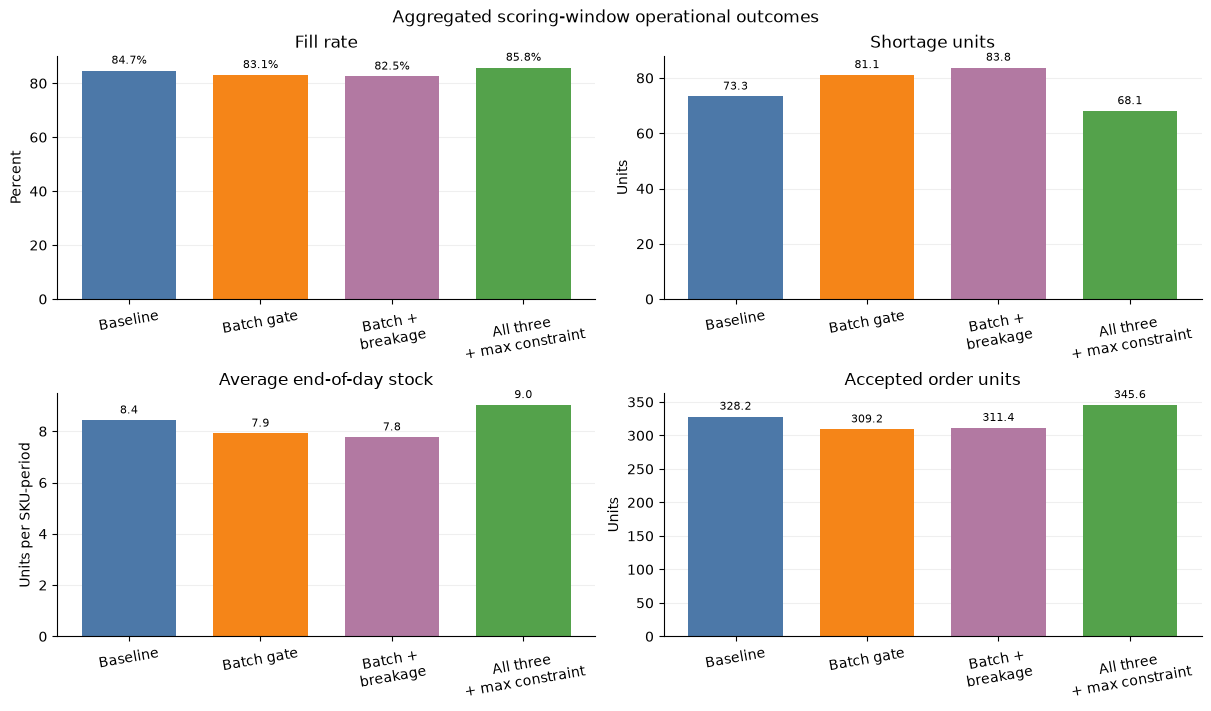

In [30]:
# Use short display labels while retaining the complete scenario names in `comparison`.
plot_results = comparison.copy()
plot_results['plot_label'] = [
    'Baseline', 'Batch gate', 'Batch +\nbreakage', 'All three\n+ max constraint',
]
plot_results['fill_rate_percent'] = 100 * plot_results['fill_rate']

# Keep one scenario color across all panels so the reader can follow a row visually.
scenario_colors = ['#4C78A8', '#F58518', '#B279A2', '#54A24B']
metric_panels = [
    ('fill_rate_percent', 'Fill rate', 'Percent', '{:.1f}%'),
    ('shortage_units', 'Shortage units', 'Units', '{:.1f}'),
    ('avg_on_hand', 'Average end-of-day stock', 'Units per SKU-period', '{:.1f}'),
    ('order_units', 'Accepted order units', 'Units', '{:.1f}'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout='constrained')
for ax, (column, title, ylabel, label_format) in zip(axes.flat, metric_panels):
    bars = ax.bar(
        plot_results['plot_label'], plot_results[column],
        color=scenario_colors, width=0.72,
    )
    # Numeric labels let the figure retain the precision needed for comparison.
    ax.bar_label(bars, labels=[label_format.format(value) for value in plot_results[column]],
                 padding=3, fontsize=8)
    ax.set(title=title, ylabel=ylabel)
    ax.tick_params(axis='x', labelrotation=10)
    ax.grid(axis='y', alpha=.2)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Aggregated scoring-window operational outcomes')
plt.show()

### Separate ordinary inventory cost from expedite intervention cost

The final cost figure uses stacked bars. The lower segment is Stockcast's ordinary holding, shortage, and ordering cost. The upper segment is the separately calculated hypothetical expedite charge. The label above each bar is their sum.

Only the final scenario has accepted expedite triggers, so the first three intervention segments are zero. The cost axis uses normalized tutorial units, not currency or observed retail economics.

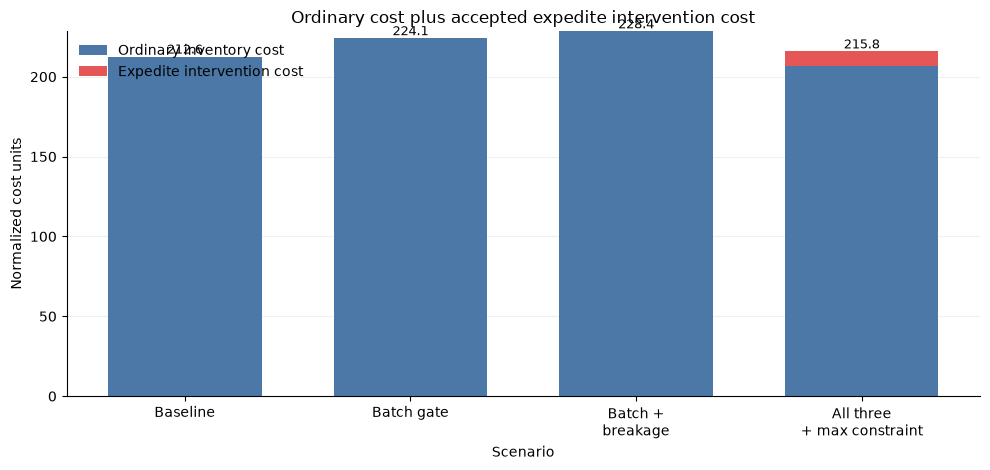

In [31]:
ordinary_costs = plot_results['ordinary_cost'].to_numpy(dtype=float)
expedite_costs = plot_results['expedite_cost'].to_numpy(dtype=float)
totals_with_interventions = plot_results['total_cost_including_interventions'].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(10, 4.8))
ordinary_bars = ax.bar(
    plot_results['plot_label'], ordinary_costs,
    color='#4C78A8', width=0.68, label='Ordinary inventory cost',
)
ax.bar(
    plot_results['plot_label'], expedite_costs, bottom=ordinary_costs,
    color='#E45756', width=0.68, label='Expedite intervention cost',
)

# Label the combined height rather than making the reader add the two segments.
for bar, total in zip(ordinary_bars, totals_with_interventions):
    ax.text(
        bar.get_x() + bar.get_width() / 2, total,
        f'{total:.1f}', ha='center', va='bottom', fontsize=9,
    )

ax.set(
    title='Ordinary cost plus accepted expedite intervention cost',
    xlabel='Scenario', ylabel='Normalized cost units',
)
ax.legend(frameon=False, loc='upper left')
ax.grid(axis='y', alpha=.2)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## What the evidence supports

The four rows are cumulative scenarios, not a leaderboard. The final row adds both priority expediting and a maximum-order constraint, so its difference from the preceding row cannot be attributed to expediting alone.

What the notebook does establish is the mechanical and auditable path:

- the batch gate can hold a policy request without storing it for later;
- the receiving adjustment is recorded after receipts and daily demand, not in transit;
- callback order changes which proposal a later callback sees;
- ordinary constraints still run after order callbacks;
- accepted effects appear in callback audit rows and in the canonical event identities; and
- callback-specific intervention cost can be kept separate and reconstructed from accepted evidence.

Whether these rules are useful in a real operation depends on supplier terms, actual breakage timing, product priorities, capacity, service objectives, and calibrated costs that this synthetic scenario does not provide. The reusable lesson is to make each assumption explicit and keep the full decision trail inspectable.